In [246]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

INPUT = "/neurospin/signatures/2026_ychaoub_rlink_predict_response_clinic/data/"


Clinical_df = pd.read_excel(INPUT + 'statistic_data.xlsx')


In [247]:
Clinical_df


,participant_id,CENTERNUM,Male sex,AGE,Current mood episode (MOODYN_PRELI),Type of episode (TYPEP_PRELI),With mixed characteristics (MIX_PRELI),Currently hospitalized (HOSP_PRELI),Weight (WEIGHT_PRELI),Height (HEIGHT_PRELI),...,Psychiatric_Comorbidity,BRMS_W1_M03,DeltaNLP,DeltaBZD,DeltaATD,SuicideAttempts(Yes/No),Delta_BMI_impute,BMI_M03,DensityEpisodes,Lithium Response (4 levels)
0,sub-10289,16,1,59,1,3.0,0.0,0.0,88.5,175.0,...,0.0,11.0,0.0,0.0,0.0,0.0,-2.122449,26.775510,0.238095,1
1,sub-11327,2,2,18,1,2.0,0.0,1.0,50.0,165.0,...,1.0,0.0,-1.0,-1.0,-1.0,0.0,1.836547,20.202020,1.333333,1
2,sub-11841,7,1,41,1,2.0,0.0,1.0,70.0,170.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.692042,24.913495,0.428571,0
3,sub-14116,12,1,28,0,NaN,NaN,NaN,85.0,178.0,...,0.0,3.0,0.0,0.0,0.0,NaN,0.000000,26.827421,NaN,1
4,sub-14393,15,2,64,1,1.0,0.0,0.0,55.0,164.0,...,0.0,0.0,NaN,NaN,NaN,0.0,0.743605,21.192742,0.571429,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,sub-96244,4,1,33,1,1.0,0.0,0.0,NaN,NaN,...,1.0,11.0,0.0,0.0,0.0,0.0,-0.850262,NaN,5.714286,1
134,sub-96357,4,2,28,1,2.0,0.0,0.0,52.0,172.0,...,1.0,16.0,0.0,1.0,0.0,0.0,0.455976,NaN,1.615385,1
135,sub-96826,15,2,40,1,1.0,0.0,1.0,68.0,159.0,...,0.0,0.0,NaN,NaN,NaN,1.0,1.582216,28.479886,1.666667,1
136,sub-98872,7,1,45,1,1.0,0.0,0.0,83.2,175.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.506122,31.673469,0.083333,0


In [248]:

### X, y ###

y = Clinical_df["Lithium Response (4 levels)"]

X = Clinical_df.drop(columns=["Lithium Response (4 levels)", "participant_id"])




# Convertir toutes les colonnes object en float
X[X.select_dtypes(include='object').columns] = (
    X.select_dtypes(include='object').astype(float)
)

# Vérification
print(X.dtypes.value_counts())




float64    197
int64       11
Name: count, dtype: int64


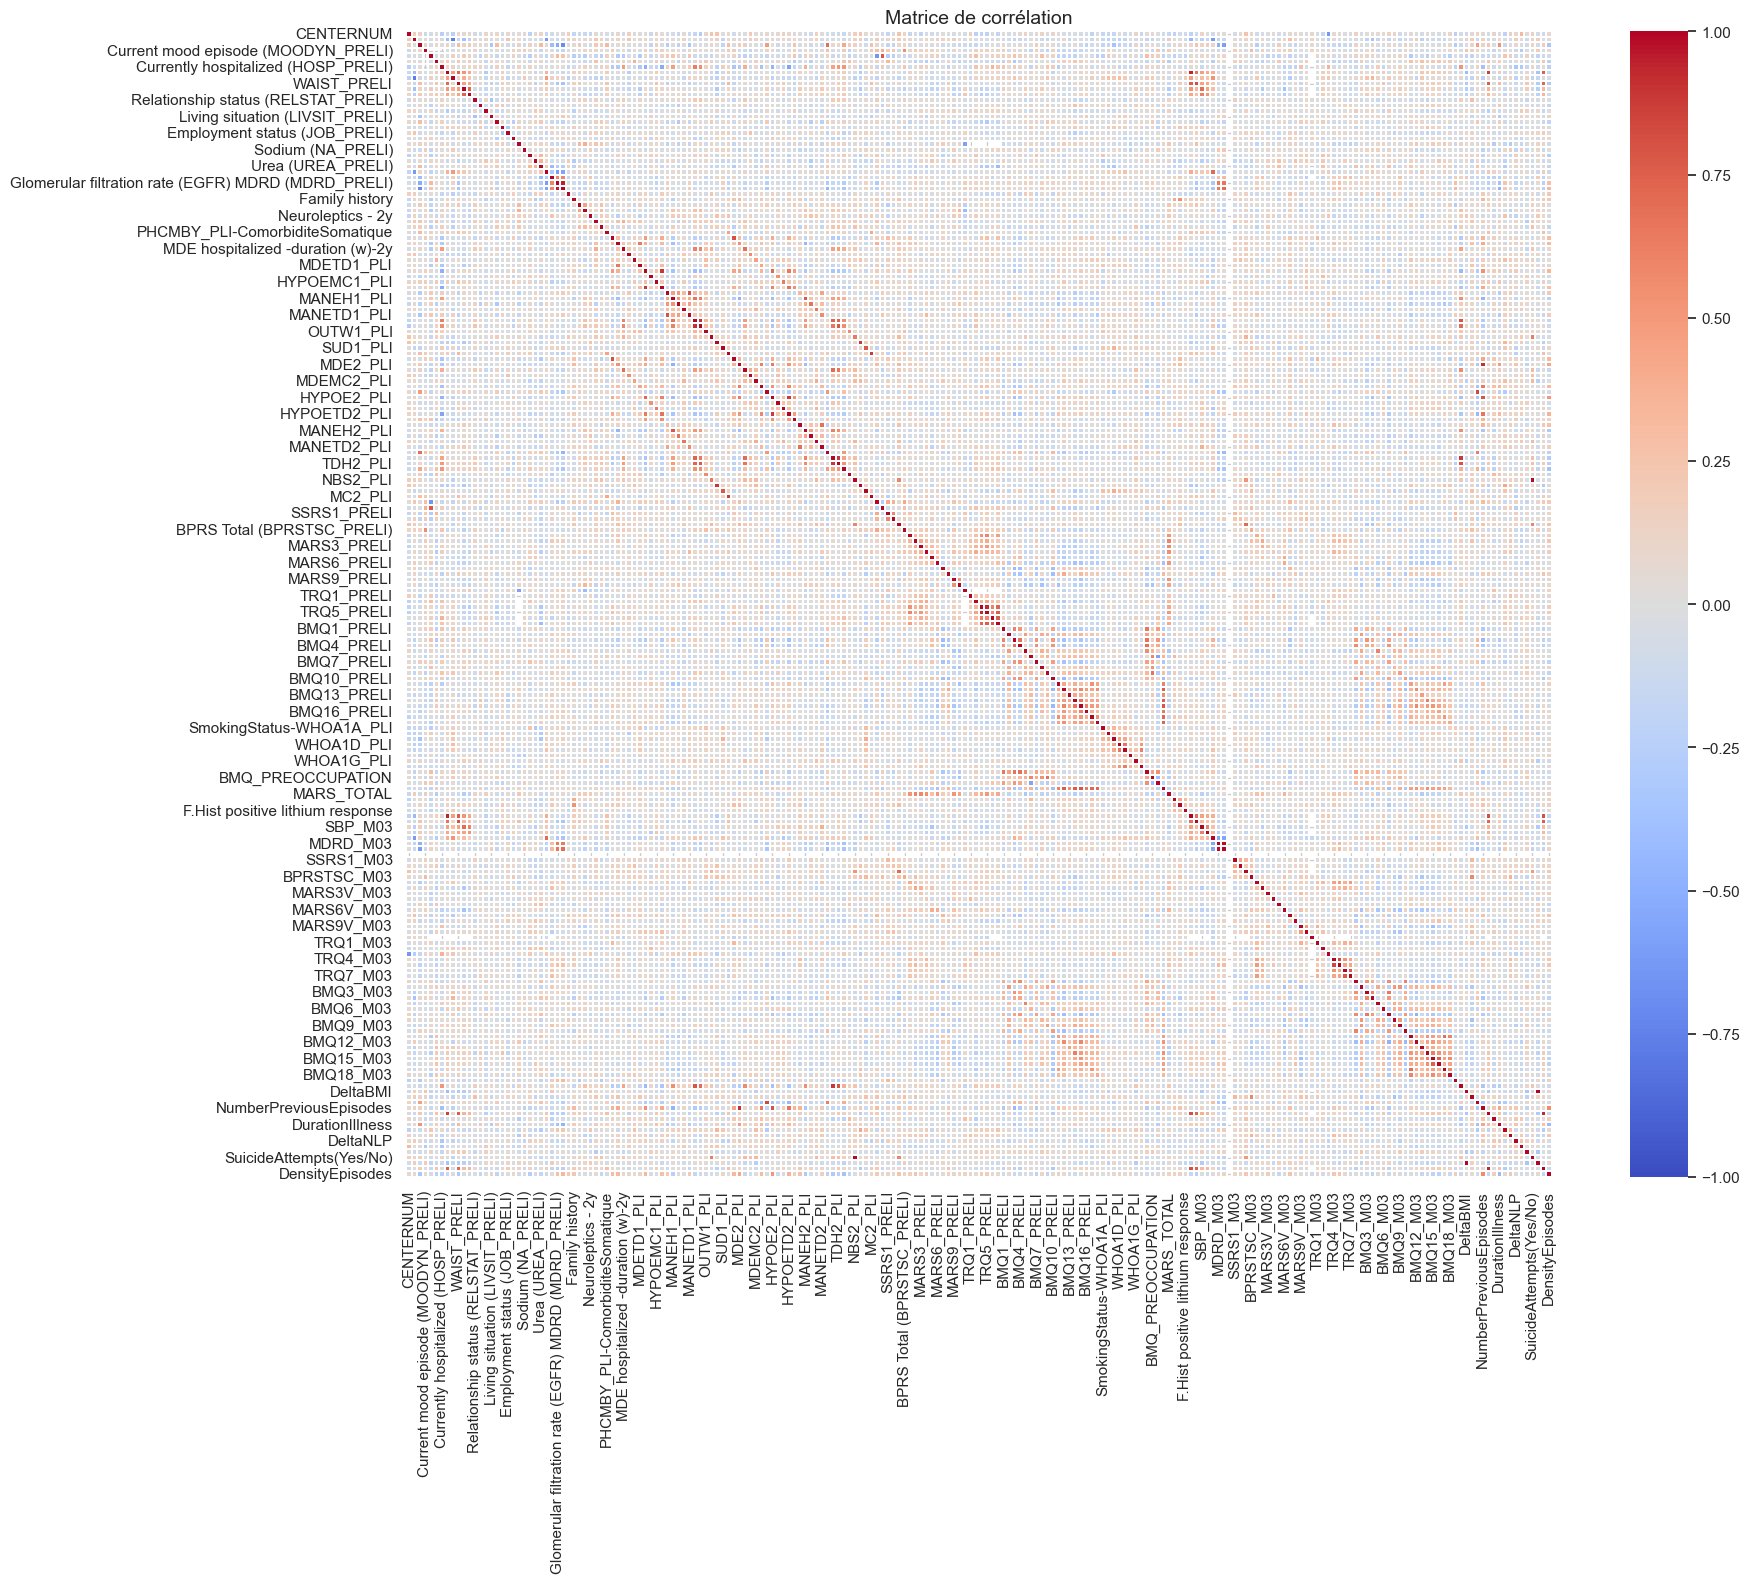

In [249]:
### Correlation matrix

corr_matrix = X.corr(method="spearman")

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=False,        
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    square=True,
)
plt.title("Matrice de corrélation", fontsize=14)
plt.tight_layout()
# plt.savefig('Matrice de correlation')
plt.show()





In [250]:


# Seuil de corrélation
threshold = 0.85

# Extraction des fortes corrélations
strong_corr = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

# Renommer les colonnes
strong_corr.columns = ['Variable_1', 'Variable_2', 'Correlation']

# Filtrer selon le seuil
strong_corr = strong_corr[
    strong_corr['Correlation'].abs() > threshold
]

# Trier par corrélation absolue décroissante
strong_corr = strong_corr.reindex(
    strong_corr['Correlation'].abs().sort_values(ascending=False).index
)

# Affichage
print(strong_corr)
strong_corr

# The most correlated variables with each other
# Variable_1                                              Variable_2                                         Correlation
# NBS2_PLI                                               SuicideAttempts(Yes/No)                             0.991790
# Glomerular filtration rate (EGFR) MDRD (MDRD_PRELI)   Glomerular filtration rate (EGFR) (CKDEPI_PRELI)     0.952948
# NBH1_PLI                                               TDH1_PLI                                            0.894335
# MDE2_PLI                                               NumberPreviousEpisodes                              0.885562
# TRQ4_PRELI                                             TRQ5_PRELI                                          0.871946
# AD1_PLI                                                AD2_PLI                                             0.870392
# NbHospitalizationsLifetime                             DensityHospit                                       0.862817
# HYPOE1_PLI                                             HYPOETD1_PLI                                        0.859697
# Weight (WEIGHT_PRELI)                                  BMI_M00                                             0.851385


                                              Variable_1  \
21169                                           DeltaBMI   
13548                                           NBS2_PLI   
19520                                           MDRD_M03   
5192   Glomerular filtration rate (EGFR) MDRD (MDRD_P...   
1549                               Weight (WEIGHT_PRELI)   
16043                                         TRQ4_PRELI   
21220                                            BMI_M00   
10704                                           MDE2_PLI   
9367                                            NBH1_PLI   
7938                                          HYPOE1_PLI   
12917                         NbHospitalizationsLifetime   
13029                         NbHospitalizationsLifetime   
10002                                            AD1_PLI   
11434                                         HYPOE2_PLI   
10301                                            MC1_PLI   
1601                               Weigh

,Variable_1,Variable_2,Correlation
21169,DeltaBMI,Delta_BMI_impute,1.000000
13548,NBS2_PLI,SuicideAttempts(Yes/No),0.991069
19520,MDRD_M03,CKDEPI_M03,0.981835
5192,Glomerular filtration rate (EGFR) MDRD (MDRD_P...,Glomerular filtration rate (EGFR) (CKDEPI_PRELI),0.948955
1549,Weight (WEIGHT_PRELI),WEIGHT_M03,0.939348
16043,TRQ4_PRELI,TRQ5_PRELI,0.935428
21220,BMI_M00,BMI_M03,0.931579
10704,MDE2_PLI,NumberPreviousEpisodes,0.909767
9367,NBH1_PLI,TDH1_PLI,0.908954
7938,HYPOE1_PLI,HYPOETD1_PLI,0.897741


BMQ  : ['BMQ1_PRELI', 'BMQ2_PRELI', 'BMQ3_PRELI', 'BMQ4_PRELI', 'BMQ5_PRELI', 'BMQ6_PRELI', 'BMQ7_PRELI', 'BMQ8_PRELI', 'BMQ9_PRELI', 'BMQ10_PRELI', 'BMQ11_PRELI', 'BMQ12_PRELI', 'BMQ13_PRELI', 'BMQ14_PRELI', 'BMQ15_PRELI', 'BMQ16_PRELI', 'BMQ17_PRELI', 'BMQ18_PRELI', 'BMQ_NECESSITY', 'BMQ_PREOCCUPATION', 'BMQ_DIFFERENTIAL', 'BMQ_GENERAL', 'BMQ1_M03', 'BMQ2_M03', 'BMQ3_M03', 'BMQ4_M03', 'BMQ5_M03', 'BMQ6_M03', 'BMQ7_M03', 'BMQ8_M03', 'BMQ9_M03', 'BMQ10_M03', 'BMQ11_M03', 'BMQ12_M03', 'BMQ13_M03', 'BMQ14_M03', 'BMQ15_M03', 'BMQ16_M03', 'BMQ17_M03', 'BMQ18_M03']
MARS : ['MARS1_PRELI', 'MARS2_PRELI', 'MARS3_PRELI', 'MARS4_PRELI', 'MARS5_PRELI', 'MARS6_PRELI', 'MARS7_PRELI', 'MARS8_PRELI', 'MARS9_PRELI', 'MARS10_PRELI', 'MARS_TOTAL', 'MARS1V_M03', 'MARS2V_M03', 'MARS3V_M03', 'MARS4V_M03', 'MARS5V_M03', 'MARS6V_M03', 'MARS7V_M03', 'MARS8V_M03', 'MARS9V_M03', 'MARS10V_M03']
TRQ  : ['TRQ_PRELI', 'TRQ1_PRELI', 'TRQ2_PRELI', 'TRQ4_PRELI', 'TRQ5_PRELI', 'TRQ6_PRELI', 'TRQ7_PRELI', 'TRQ_M03', 'TR

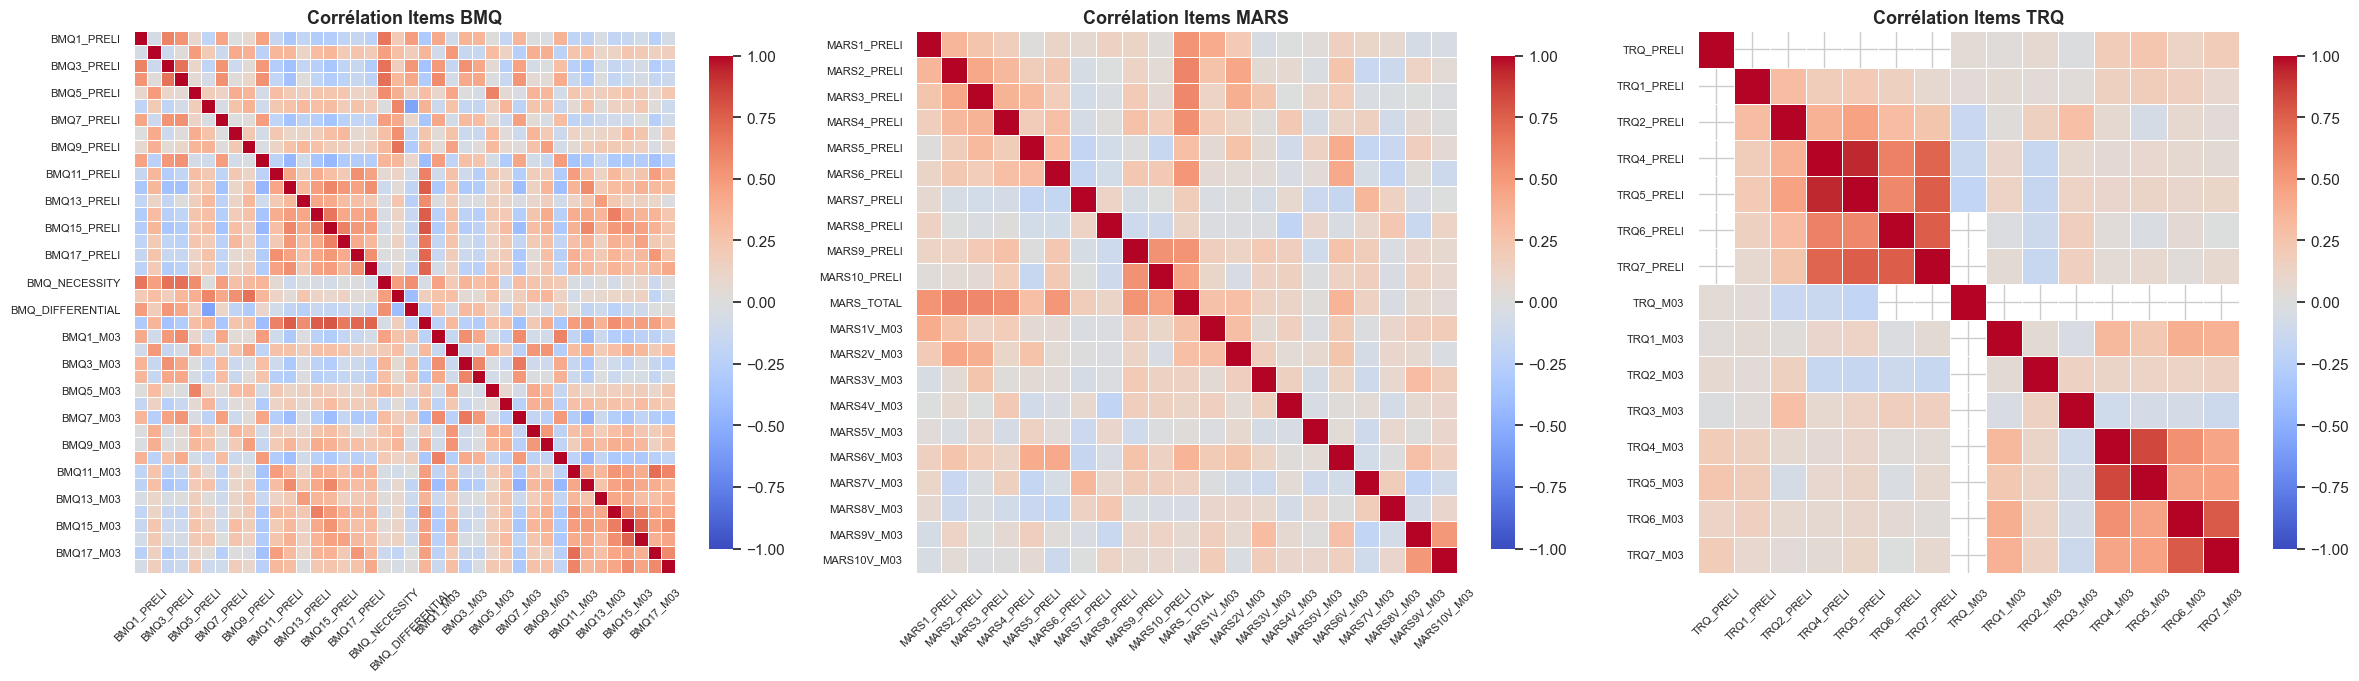

In [251]:

## Correlation of BMQ, MARS and TRQ
#  Sélection des variables 
bmq_cols  = [c for c in X.columns if 'BMQ'  in str(c)]
mars_cols = [c for c in X.columns if 'MARS' in str(c)]
trq_cols  = [c for c in X.columns if 'TRQ'  in str(c)]

print("BMQ  :", bmq_cols)
print("MARS :", mars_cols)
print("TRQ  :", trq_cols)

#  Matrices de corrélation 
corr_bmq  = X[bmq_cols].corr(method="spearman")
corr_mars = X[mars_cols].corr(method="spearman")
corr_trq  = X[trq_cols].corr(method="spearman")

#  Visualisation 
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- BMQ ---
sns.heatmap(corr_bmq,
            ax=axes[0],
            annot=False,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.4,
            square=True,
            cbar_kws={"shrink": 0.8})

axes[0].set_title("Corrélation Items BMQ",
                  fontsize=13,
                  fontweight="bold")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

# --- MARS ---
sns.heatmap(corr_mars,
            ax=axes[1],
            annot=False,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.4,
            square=True,
            cbar_kws={"shrink": 0.8})

axes[1].set_title("Corrélation Items MARS",
                  fontsize=13,
                  fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0, labelsize=8)

# --- TRQ ---
sns.heatmap(corr_trq,
            ax=axes[2],
            annot=False,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.4,
            square=True,
            cbar_kws={"shrink": 0.8})

axes[2].set_title("Corrélation Items TRQ",
                  fontsize=13,
                  fontweight="bold")
axes[2].tick_params(axis="x", rotation=45, labelsize=8)
axes[2].tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()

# plt.savefig("corr_bmq_mars_trq.png",dpi=150,bbox_inches="tight")

plt.show()




In [252]:


### Multicolinerarity assessment: Matrix and VIF 

# ── Calcul du VIF ─────────────────────────────────────────────────────────────
def compute_vif(X):
    vif = pd.DataFrame()
    vif["feature"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)

X_no_nan = X.select_dtypes(include=["number"]).dropna()
vif_df = compute_vif(X_no_nan)
print(vif_df)


# The VIF results contain infinite values, which confirms the presence of multicollinearity,
# therefore we will apply regularization methods to handle it in the models

         feature  VIF
0      CENTERNUM  inf
1     WHOA1G_PLI  inf
2    BMQ16_PRELI  inf
3    BMQ17_PRELI  inf
4    BMQ18_PRELI  inf
..           ...  ...
203     TRQ1_M03  NaN
204     TRQ2_M03  NaN
205     TRQ5_M03  NaN
206     TRQ7_M03  NaN
207  BRMS_W1_M03  NaN

[208 rows x 2 columns]


/home/yc287630/.local/lib/python3.8/site-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/yc287630/.local/lib/python3.8/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/home/yc287630/.local/lib/python3.8/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [253]:
# Corrélation entre y et toutes les variables
correlations = X.corrwith(y)

# Trier par corrélation absolue
correlations = correlations.sort_values(key=abs, ascending=False)

print(correlations)

Antidepressants - 2y       0.257464
TRQ1_PRELI                -0.226221
Urea (UREA_PRELI)         -0.209255
QIDS_W1_M03                0.182865
BRMS_W1_M03                0.177093
                             ...   
HYPOEMC1_PLI              -0.002271
Psychiatric_Comorbidity    0.001916
DurationIllness            0.001631
NumberPreviousEpisodes    -0.000846
CURRMED_M03                     NaN
Length: 208, dtype: float64


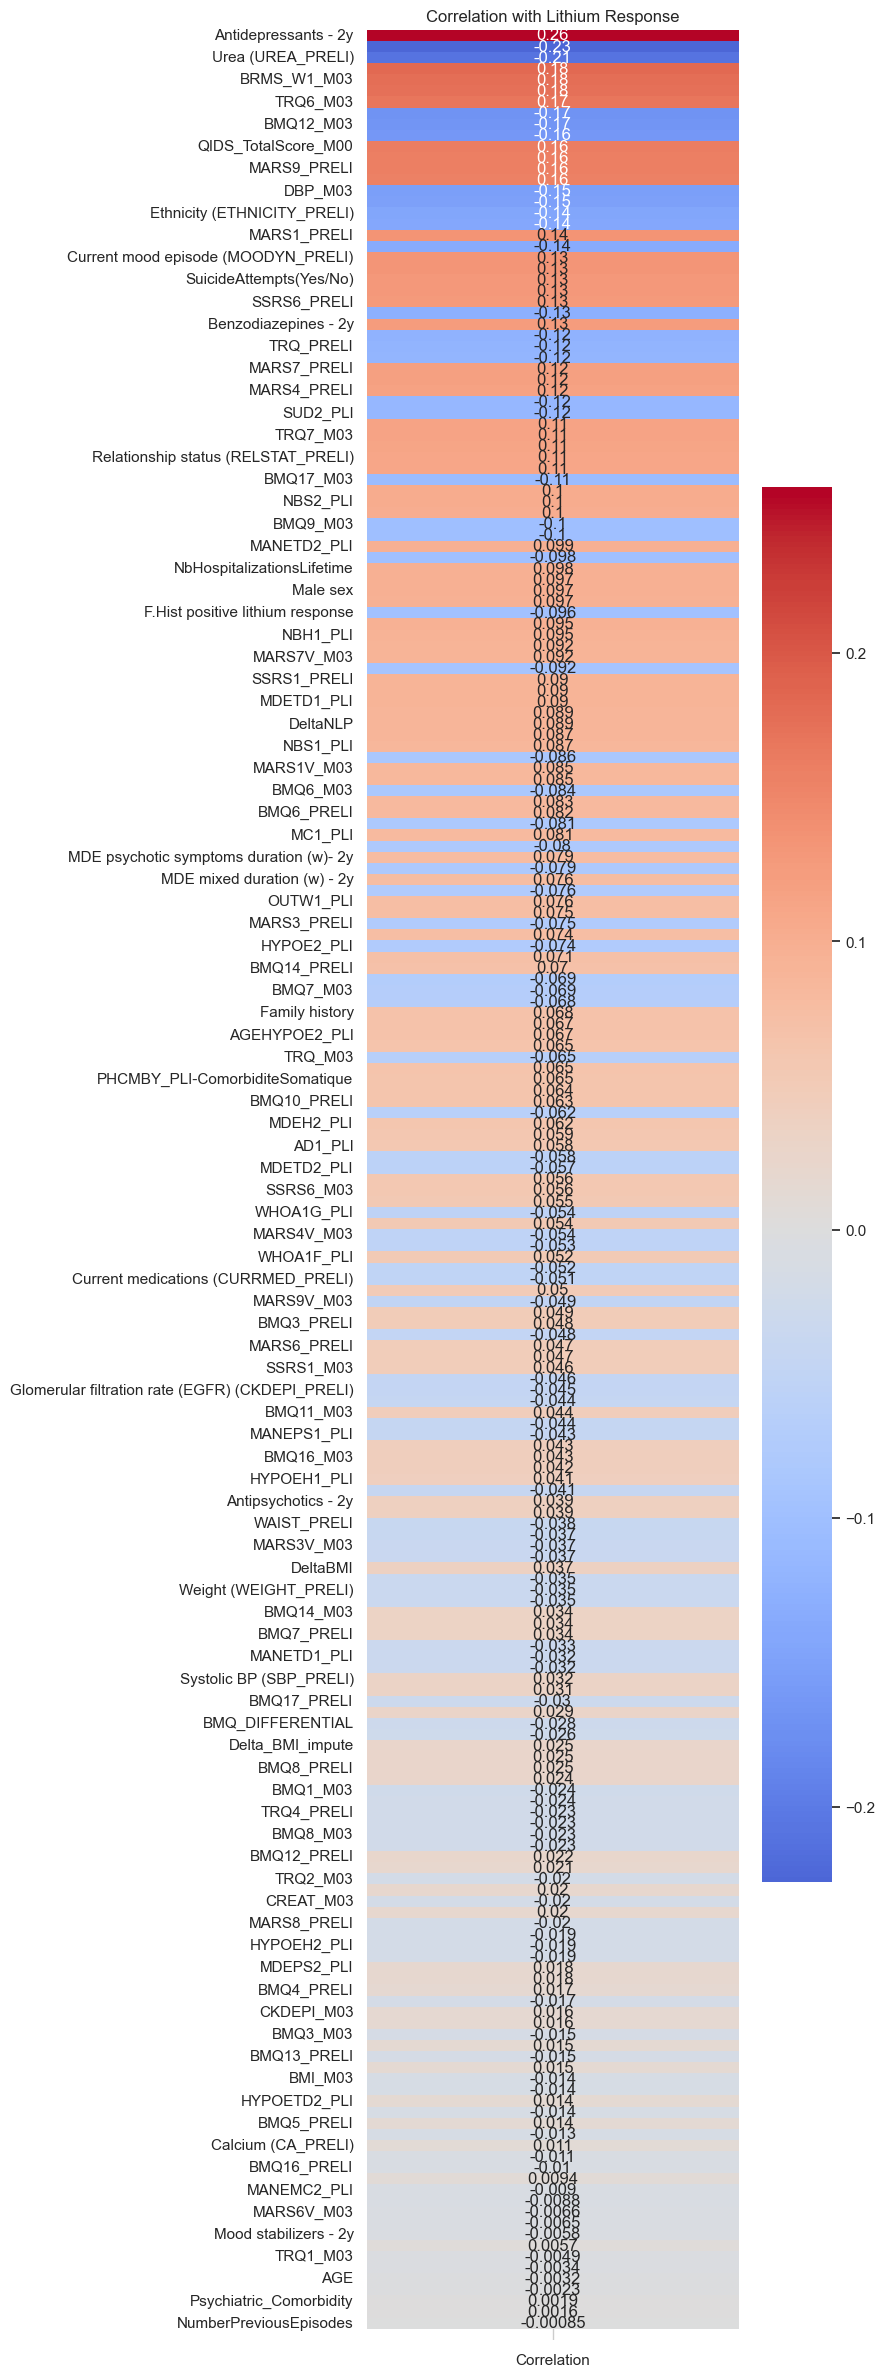

In [254]:

corr_df = correlations.to_frame(name="Correlation")

plt.figure(figsize=(6, 30))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation with Lithium Response")
plt.show()

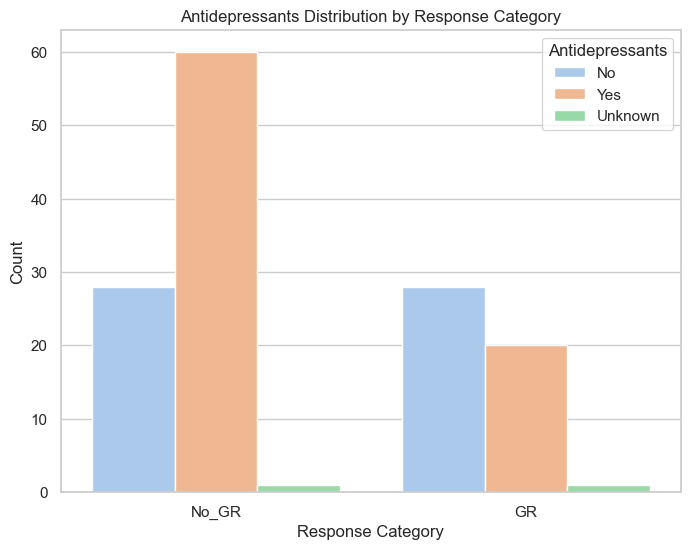

In [255]:
# Mapping variables
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

Clinical_df['Antidep'] = Clinical_df['Antidepressants - 2y'].map({
    1: 'Yes',
    0: 'No'
}).fillna('Unknown')

# Plot
plt.figure(figsize=(8,6))

sns.countplot(
    x="response_label",
    hue="Antidep",
    data=Clinical_df,
    palette='pastel'
)

plt.title('Antidepressants Distribution by Response Category')
plt.xlabel('Response Category')
plt.ylabel('Count')
plt.legend(title='Antidepressants')

plt.show()

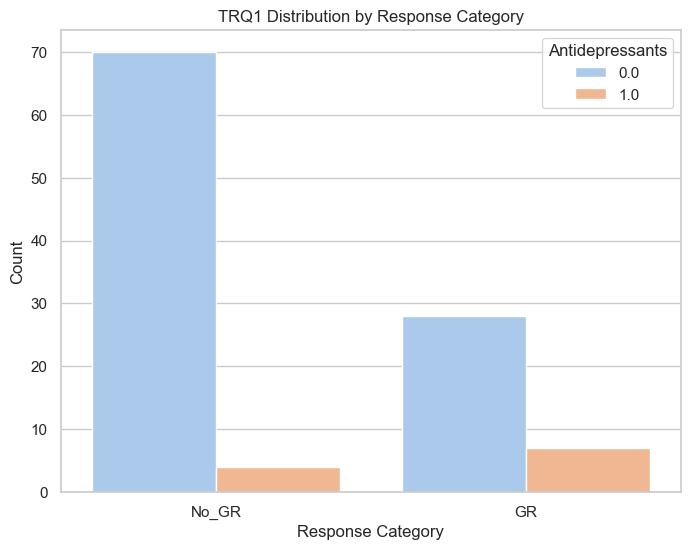

In [256]:
# Mapping variables
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

Clinical_df['TRQ1_label'] = Clinical_df['TRQ1_PRELI'].map({
    1: 'Yes',
    0: 'No'
}).fillna('Unknown')

# Plot
plt.figure(figsize=(8,6))

sns.countplot(
    x="response_label",
    hue="TRQ1_PRELI",
    data=Clinical_df,
    palette='pastel'
)

plt.title('TRQ1 Distribution by Response Category')
plt.xlabel('Response Category')
plt.ylabel('Count')
plt.legend(title='Antidepressants')

plt.show()

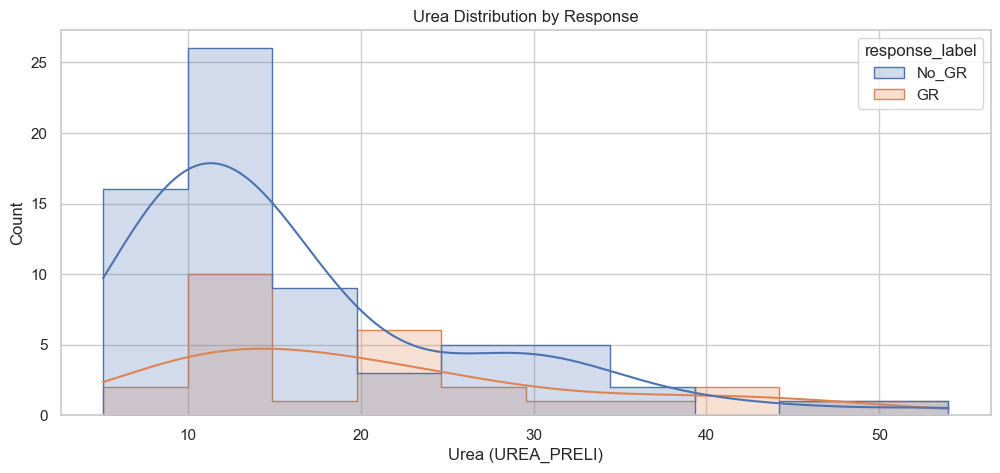

In [257]:
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

plt.figure(figsize=(12,5))
sns.histplot(
    data=Clinical_df,
    x='Urea (UREA_PRELI)',
    hue="response_label",
    kde=True,
    element="step"
)

plt.title("Urea Distribution by Response")
#plt.savefig('Distribution de Urea en fct de Response')

plt.show()

In [258]:
#Descriptive Statistics
Clinical_df.describe().round(2)

,CENTERNUM,Male sex,AGE,Current mood episode (MOODYN_PRELI),Type of episode (TYPEP_PRELI),With mixed characteristics (MIX_PRELI),Currently hospitalized (HOSP_PRELI),Weight (WEIGHT_PRELI),Height (HEIGHT_PRELI),WAIST_PRELI,...,Psychiatric_Comorbidity,BRMS_W1_M03,DeltaNLP,DeltaBZD,DeltaATD,SuicideAttempts(Yes/No),Delta_BMI_impute,BMI_M03,DensityEpisodes,Lithium Response (4 levels)
count,138.00,138.00,138.00,138.00,88.00,88.00,88.00,128.00,126.00,100.00,...,135.00,132.00,121.00,121.00,121.0,133.00,138.00,111.00,125.00,138.00
mean,8.76,1.51,40.31,0.64,1.64,0.17,0.47,78.01,171.62,91.63,...,0.36,2.03,-0.06,-0.07,-0.1,0.24,0.43,26.37,1.47,0.64
std,4.60,0.50,12.98,0.48,0.76,0.38,0.50,18.91,10.02,17.72,...,0.48,3.70,0.23,0.49,0.4,0.43,1.57,4.95,1.85,0.48
min,1.00,1.00,18.00,0.00,1.00,0.00,0.00,49.00,150.00,31.00,...,0.00,0.00,-1.00,-1.00,-1.0,0.00,-5.17,18.93,0.08,0.00
25%,5.00,1.00,28.00,0.00,1.00,0.00,0.00,62.90,164.00,80.75,...,0.00,0.00,0.00,0.00,0.0,0.00,-0.33,22.39,0.43,0.00
50%,9.00,2.00,40.00,1.00,1.00,0.00,0.00,75.25,171.00,90.00,...,0.00,0.00,0.00,0.00,0.0,0.00,0.43,25.48,1.00,1.00
75%,12.00,2.00,52.00,1.00,2.00,0.00,1.00,88.28,178.75,103.00,...,1.00,2.00,0.00,0.00,0.0,0.00,1.05,29.10,1.75,1.00
max,16.00,2.00,69.00,1.00,3.00,1.00,1.00,163.00,194.00,135.00,...,1.00,16.00,0.00,1.00,1.0,1.00,6.46,47.11,11.67,1.00


In [259]:
sns.set_theme(style="whitegrid")

Text(0.5, 1.0, 'Age Distribution')

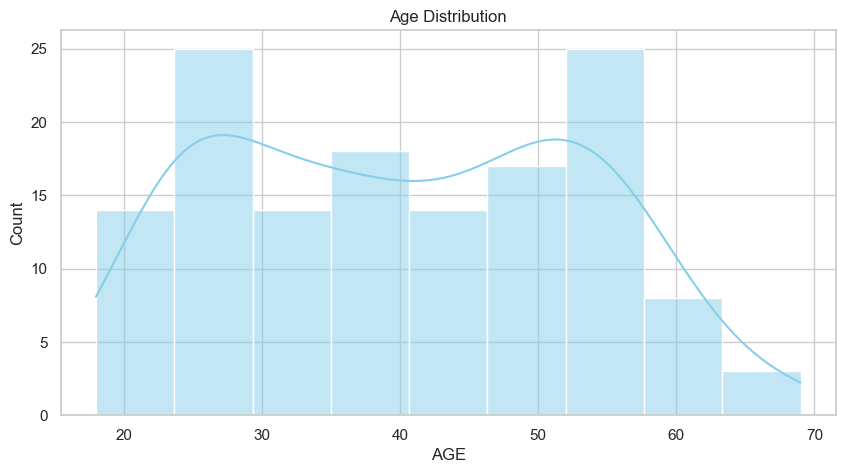

In [260]:
#Distribution of Age
plt.figure(figsize=(10,5))


sns.histplot(Clinical_df["AGE"],kde=True,color='skyblue')
plt.title('Age Distribution')


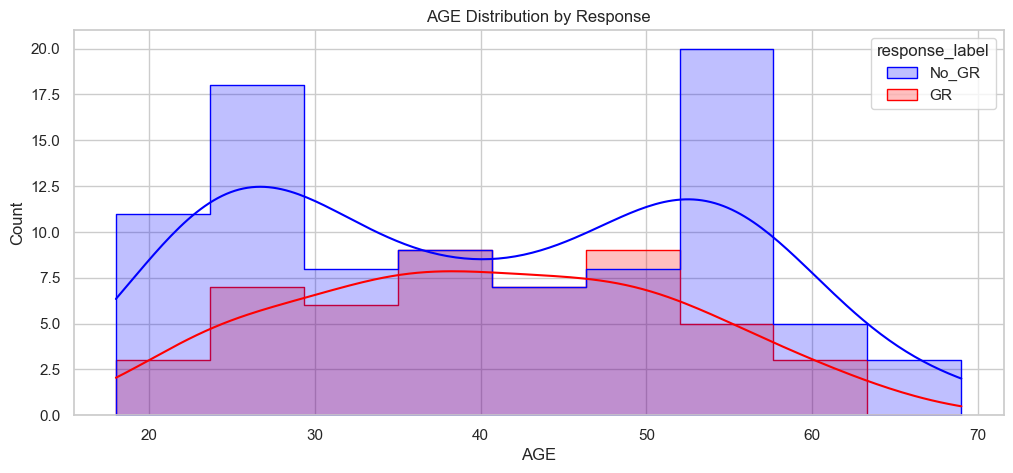

In [261]:
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

plt.figure(figsize=(12,5))
sns.histplot(
    data=Clinical_df,
    x="AGE",
    hue="response_label",
    kde=True,
    element="step",
    palette={"GR":"red", "No_GR":"blue"}
)

plt.title("AGE Distribution by Response")
#plt.savefig('Distribution de AGE en fct de Response')

plt.show()

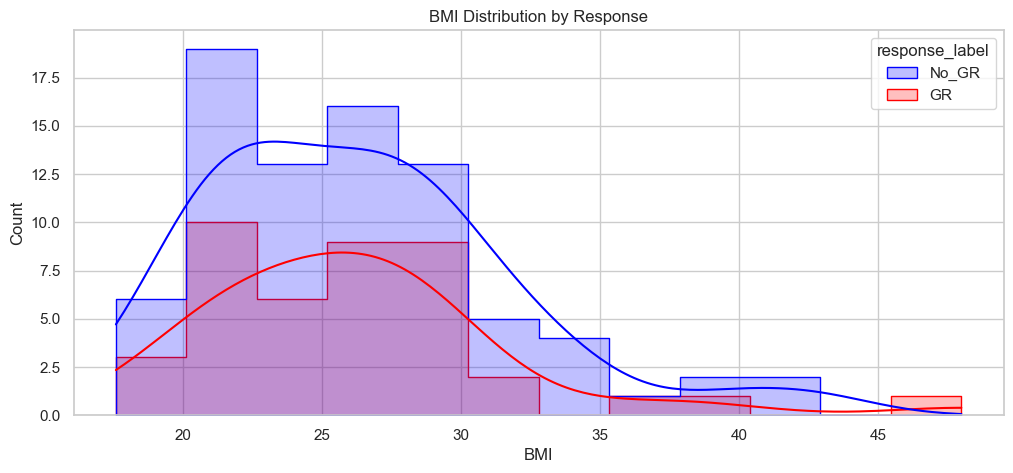

In [262]:
# Response mapping
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

# BMI Distribution
plt.figure(figsize=(12,5))

sns.histplot(
    data=Clinical_df,
    x="BMI_M00",
    hue="response_label",
    kde=True,
    element="step",
    palette={"GR": "red", "No_GR": "blue"}
)

plt.title('BMI Distribution by Response')
plt.xlabel('BMI')
plt.ylabel('Count')

#plt.savefig('BMI_Distribution_by_Response.png', dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_2066541/2426767212.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


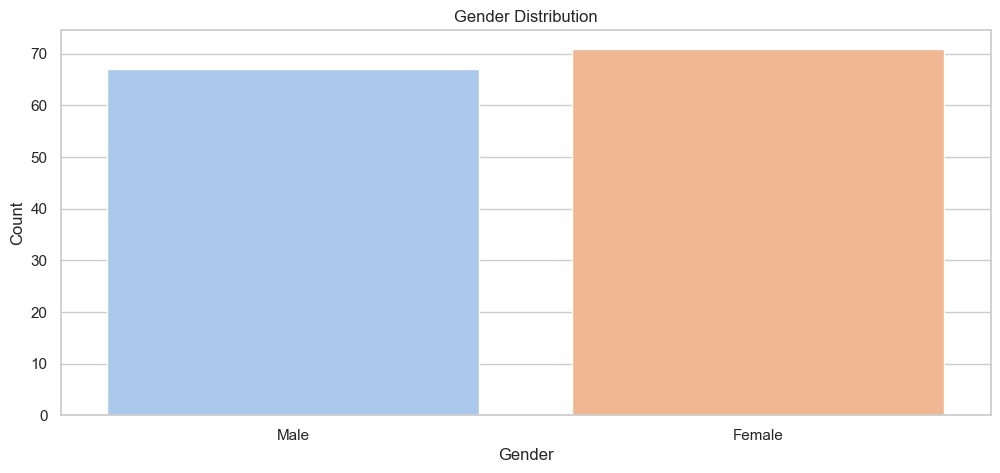

In [263]:
# Map SEX values to labels
Clinical_df['SEX_label'] = Clinical_df['Male sex'].map({
    1: 'Male',
    2: 'Female',
    3: 'Other'
})

# Gender distribution plot
plt.figure(figsize=(12,5))

sns.countplot(
    x="SEX_label",
    data=Clinical_df,
    palette='pastel'
)

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')


plt.show()

/tmp/ipykernel_2066541/3415178551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')


Text(0.5, 1.0, 'output Distribution')

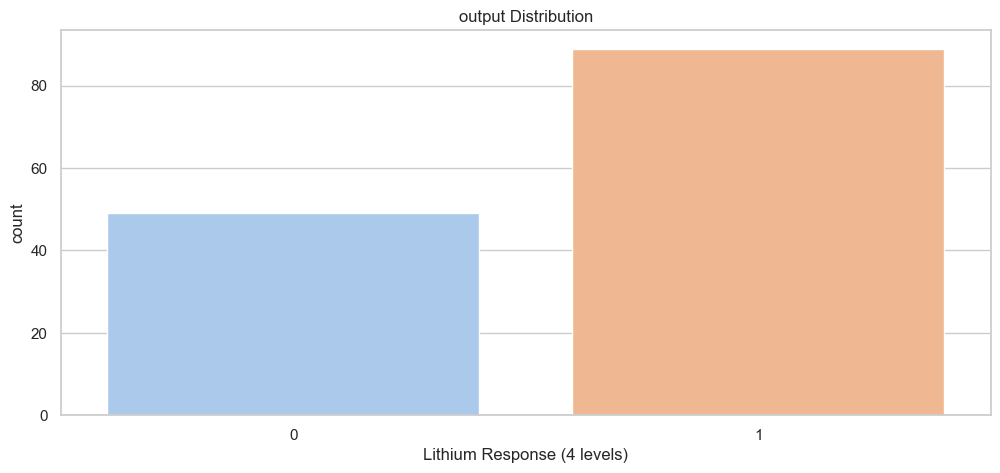

In [264]:
#Variable OUTPUT

plt.figure(figsize=(12,5))
sns.countplot(x="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('output Distribution')

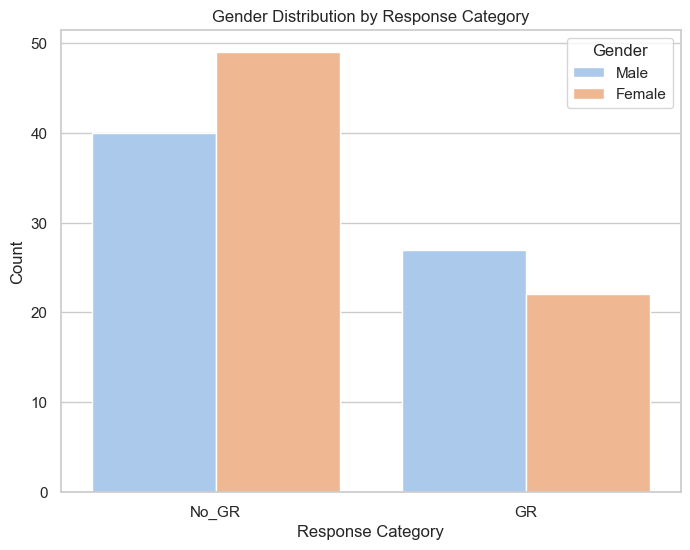

In [265]:
# Mapping variables
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

Clinical_df['SEX_label'] = Clinical_df['Male sex'].map({
    1: 'Male',
    2: 'Female',
    3: 'Other'
})

# Plot
plt.figure(figsize=(8,6))

sns.countplot(
    x="response_label",
    hue="SEX_label",
    data=Clinical_df,
    palette='pastel'
)

plt.title('Gender Distribution by Response Category')
plt.xlabel('Response Category')
plt.ylabel('Count')

plt.legend(title='Gender')


plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

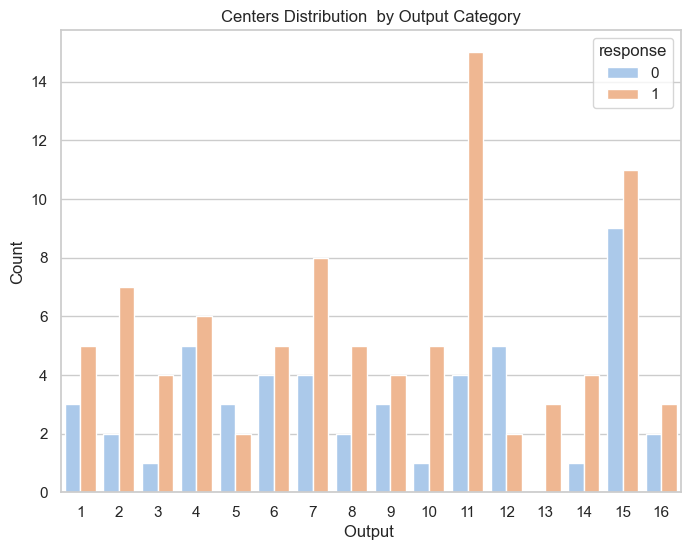

In [266]:
plt.figure(figsize=(8,6))
sns.countplot(x="CENTERNUM",hue="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('Centers Distribution  by Output Category')
plt.xlabel('Output ')
plt.ylabel('Count')
plt.legend(title='response')
plt.show

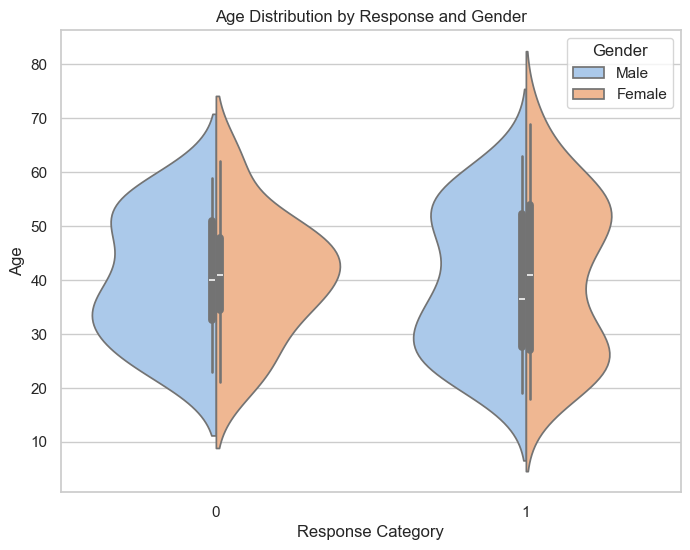

In [267]:
# variable numérique : AGE

plt.figure(figsize=(8,6))

sns.violinplot(
    x="Lithium Response (4 levels)",
    y="AGE",
    hue="SEX_label",
    data=Clinical_df,
    palette="pastel",
    split=True
)

plt.title('Age Distribution by Response and Gender')
plt.xlabel('Response Category')
plt.ylabel('Age')

plt.legend(title='Gender')

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

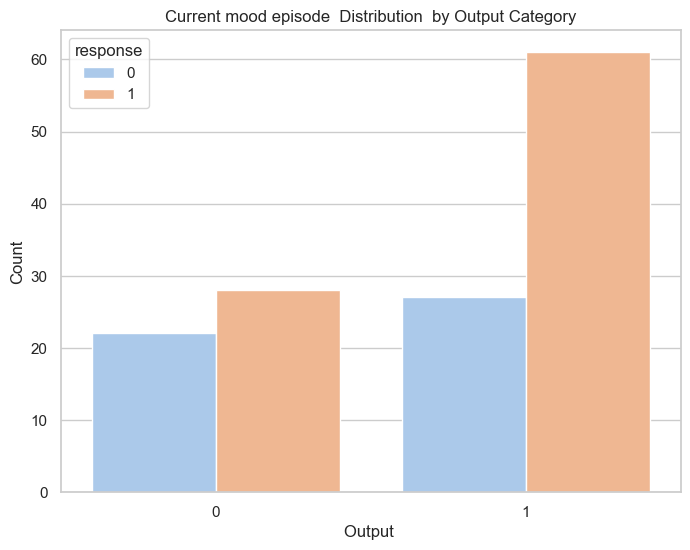

In [268]:
plt.figure(figsize=(8,6))
sns.countplot(x="Current mood episode (MOODYN_PRELI)",hue="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('Current mood episode  Distribution  by Output Category')
plt.xlabel('Output ')
plt.ylabel('Count')
plt.legend(title='response')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

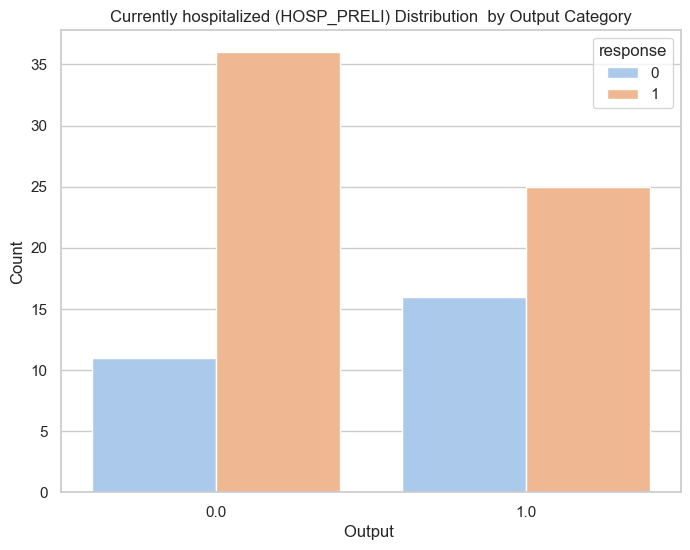

In [269]:
plt.figure(figsize=(8,6))
sns.countplot(x="Currently hospitalized (HOSP_PRELI)",hue="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('Currently hospitalized (HOSP_PRELI) Distribution  by Output Category')
plt.xlabel('Output ')
plt.ylabel('Count')
plt.legend(title='response')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

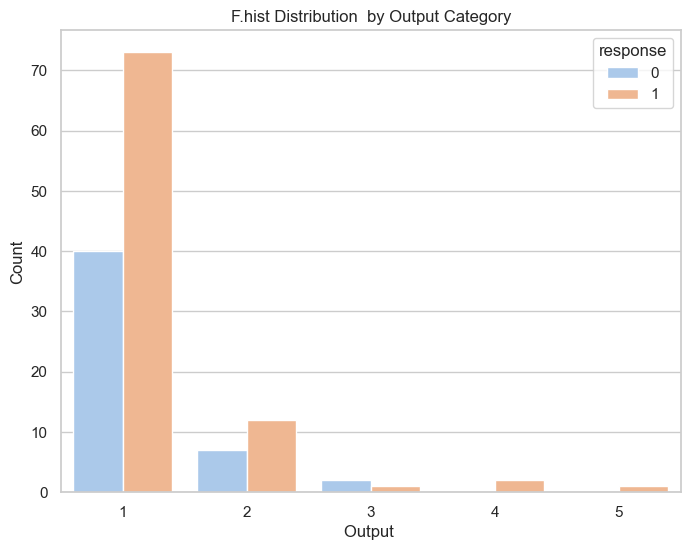

In [270]:
plt.figure(figsize=(8,6))
sns.countplot(x="F.hist absolute count",hue="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('F.hist Distribution  by Output Category')
plt.xlabel('Output ')
plt.ylabel('Count')
plt.legend(title='response')
plt.show

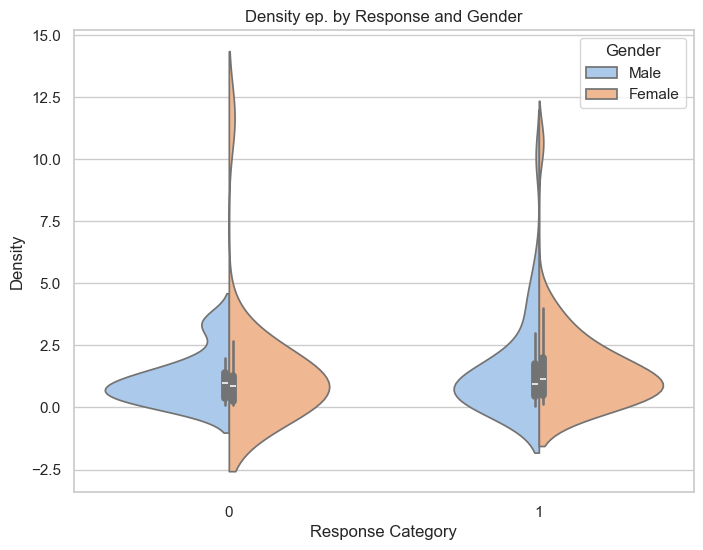

In [271]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x="Lithium Response (4 levels)",
    y="DensityEpisodes",
    hue="SEX_label",
    data=Clinical_df,
    palette="pastel",
    split=True
)

plt.title('Density ep. by Response and Gender')
plt.xlabel('Response Category')
plt.ylabel('Density')

plt.legend(title='Gender')

#plt.savefig('Violin_Age_by_Response.png',dpi=300,bbox_inches='tight')

plt.show()

In [272]:
# %%
Clinical_df.loc[Clinical_df['DensityEpisodes'] < 0, 'DensityEpisodes']

Series([], Name: DensityEpisodes, dtype: float64)

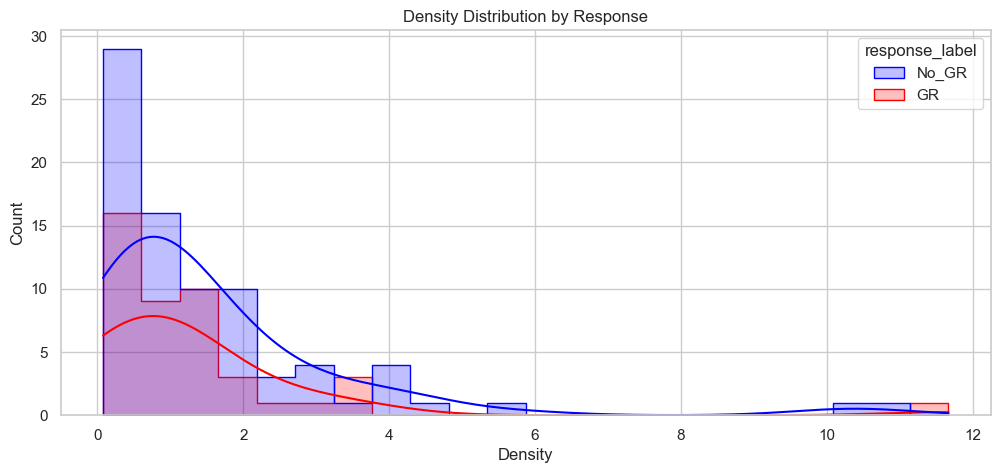

In [273]:
# Response mapping
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

# BMI Distribution
plt.figure(figsize=(12,5))

sns.histplot(
    data=Clinical_df,
    x="DensityEpisodes",
    hue="response_label",
    kde=True,
    element="step",
    palette={"GR": "red", "No_GR": "blue"}
)

plt.title('Density Distribution by Response')
plt.xlabel('Density')
plt.ylabel('Count')

#plt.savefig('BMI_Distribution_by_Response.png', dpi=300, bbox_inches='tight')

plt.show()